<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> Polynomial Regression </h2>
</div>


### Polynomial Regression 		

- Which is not having any linear curve, those are polynomial regression. It will be like parabola or exponential curve

- 1st draw the curve on existing data i/p and o/p, based on its shape, we can decide its linear or plynomial regression we need to use
		
##### Polynomial Features	
		
- Features(input column) are something we use to distinguish one object from others, So obviously, if we have more Features, then we will likely have a better fit model, since it can receive more necessary information for training. 
		
- The easiest way to add more Features(Column), is to computing polynomial features from the provided features.
		
- It means that if we have X, then we can use X2(X square), X3(X cube), etc as additional features
		
- Here square, cube are called as degree 2,3 respectively
		
- Some times poynomial feature applied dataset will gives better model score compared to simple model.
		
##### Degree	
		
- In Model initiation time we will give degree as some value, this we will give randomly, there is no specific way to find perfect degree. With trail and error method we need to find perfect degree
		
		
		
		
		x_poly = poly_reg.fit_transform(X)
		
		
		x_poly = poly_reg.transform(X_TEST)
		
		

- In this regression linear model only applied, but data is convered to linear data by using polynomial feature related model/Func, then this linear converted data used in linear model to build the model


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


## Problem: Build a Polynomial linear Regression predictor which can predict
 the Salary if we provide the level. So we can guess whether a particular person with that level is telling truth or lie about is salary.
 
 We are using the same dataset, in which we want to predict the salary for a new employee whose level of experience is 6.5 and he said that the previous company paid him 160000 and he wants a higher salary and we have got some data which has three columns- Position, Level and Salary. then here we will use polynomial regression to predict his salary based on the data we have.
 
 In the I/P data we have level and salary.

Types of regression:
1. Simple Linear Regression Y = a + bX
2. Multiple Linear Regression Y = a +bX1 + cX2 + dX3 +....Xn
3. Polynomial LR: Y = a + bX + cX^2 + dX^3 + .....+X^n
i.e when O/P is having a polynomial relationship with input
"""

> # Here input vs output is not linear line, its polynomial or Non linear relationship
Simply look at the data distribution, if it is anything close to Non linear like curve then diectly apply polynomial and see

>  And op is salary which is continous not categorial so we need to use some regression model

> Polynomial Regression is a form of linear regression in which the relationship between the independent variable x and dependent variable y is not linear but it is the nth degree of polynomial.

>> So we apply PolynomialFeatures and convert ip from non linear to linear relationsip data by converting it to some degree
> Then we apply linear regression on it

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
dataset = pd.read_csv('../Dataset/Position_Salaries.csv')
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


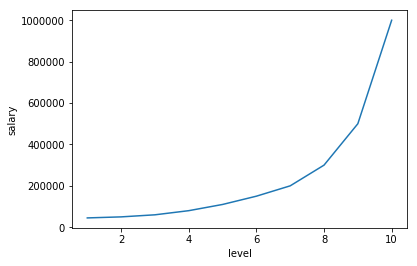

In [23]:
plt.plot(dataset['Level'], dataset['Salary'])
plt.xlabel('level')
plt.ylabel('salary')
plt.show()
#Level vs salary is not linear, its little curve, so just by level we cant predict salary in linear regression graph

In [24]:
X = dataset['Level']
Y = dataset['Salary']

In [25]:
Y.head()

0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64

In [26]:
X = dataset.iloc[:,1:2].values  # LEVEL considered, Position not required
Y = dataset.iloc[:,2].values   # Salary

print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


## Fitting the dataset with Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,Y)

predicted_op = lin_reg.predict(X)
predicted_op

array([-114454.54545455,  -33575.75757576,   47303.03030303,
        128181.81818182,  209060.60606061,  289939.39393939,
        370818.18181818,  451696.96969697,  532575.75757576,
        613454.54545455])

#Me tried, some error, for linear regression we should check MSE, RMSE, Not accuracy score. It shows error

from sklearn import metrics
##### quatify the performance of the model Using linear regression
metrics.accuracy_score(Y, predicted_op)
#To avoide above error, round the data , both shound be integer
metrics.accuracy_score(Y, predicted_op.round())

## Here MODEL EVALUATION WITH RMSE is not required


# MAE RMSE, MSE are only used if o/p is continous numeric value not for categorial o/p means for Linear regression problem. Not for Logistic regression not for categorial o/p

## This Error should be less
#Print Mean Absolute Error MAE
print("MAE :" , metrics.mean_absolute_error(Y, predicted_op))

#Print Mean Squared Error MSE
print("MSE :" , metrics.mean_squared_error(Y, predicted_op))

#Print Root Mean Squared Error RMSE
print("RMSE :" , np.sqrt(metrics.mean_squared_error(Y, predicted_op)))


# Fitting the dataset with Polynomial Regression

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)

# converting non-linear data to Linear data. Apply only to input Feature
X_poly = poly_reg.fit_transform(X)
print(X_poly)

# Apply Linear Regression on Polynomial transformed input data
lin_reg2 = LinearRegression()
#This ploynomial linear converted data only fit into linear model -->this is the way polynomial applied
lin_reg2.fit(X_poly, Y)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

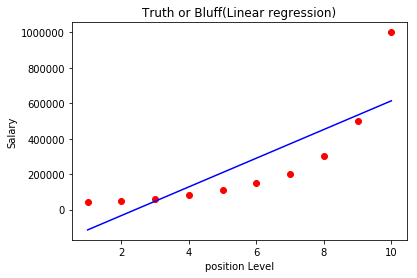

In [30]:
# Visualizing the Linear Regression result
plt.scatter(X,Y, color='red')
plt.plot(X, predicted_op, color='blue')
plt.title("Truth or Bluff(Linear regression)")
plt.xlabel("position Level")
plt.ylabel("Salary")
plt.show()

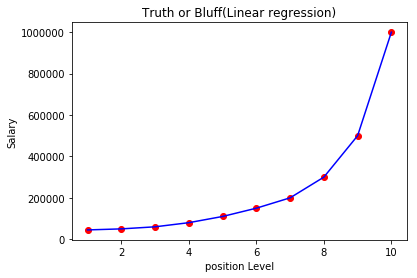

In [31]:
# visualizing the polynomial results
plt.scatter(X,Y, color='red')
#Y = lin_reg2.predict(poly_reg.fit_transform(X))
Y_new_predicted = lin_reg2.predict(X_poly)
plt.plot(X,Y, color='blue')
plt.title("Truth or Bluff(Linear regression)")
plt.xlabel("position Level")
plt.ylabel("Salary")
plt.show()

## Here MODEL EVALUATION WITH RMSE not required

# MAE RMSE, MSE are only used if o/p is continous numeric value not for categorial o/p means for Linear regression problem. Not for Logistic regression not for categorial o/p

## This Error should be less
#Print Mean Absolute Error MAE
print("MAE :" , metrics.mean_absolute_error(Y, Y_new_predicted))

#Print Mean Squared Error MSE
print("MSE :" , metrics.mean_squared_error(Y, Y_new_predicted))

#Print Root Mean Squared Error RMSE
print("RMSE :" , np.sqrt(metrics.mean_squared_error(Y, Y_new_predicted)))


In [33]:
Position,Level,Salary
Business Analyst,1,45000
Junior Consultant,2,50000
Senior Consultant,3,60000
Manager,4,80000
Country Manager,5,110000
Region Manager,6,150000
Partner,7,200000
Senior Partner,8,300000
C-level,9,500000
CEO,10,1000000

SyntaxError: invalid syntax (<ipython-input-33-4846c50c0f44>, line 2)

## MODEL VALIDATION

In [37]:
#predictig the result of linear regression model.
lin_reg.predict( ([ [6.5] ]) )

array([330378.78787879])

#### It predicts 3,30,378, which is not even close to what the person said which is 1,60,000.

Now let's predict the result of polynomial regression model.

In [36]:
#predicting the result of polynomial regression.
lin_reg2.predict( poly_reg.fit_transform(([ [6.5] ]) ))

array([158862.45265153])

### It predicts 158862.452, which is quite close to what the person said. This means that the polynomial regression models gives us a much more accurate prediction.

# Conclusion
We can see that our polynomial model predicted a much realistic salary which is actually in between the salaries of level 6 and 7. Look at how poorly the linear regression has performed. Now you might wonder, why I have considered only degree 4 for this problem. Well, I encourage you to try different degrees and see the results for your results. Try degree=2,3,4,5,6 etc